# Exercise 1B: Moving Averages
**BUSI 722: Data-Driven Finance II**

Using the monthly dataset built in Exercise 1A, compute moving averages and
evaluate their predictive power for future stock returns.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_parquet("exercise01_data.parquet")
df = df.sort_values(["ticker", "month"]).reset_index(drop=True)
print(f"Loaded: {len(df):,} rows, {df['ticker'].nunique()} tickers")
print(f"Date range: {df['month'].min()} to {df['month'].max()}")

Loaded: 171,590 rows, 5239 tickers
Date range: 2022-02 to 2026-01


## 1--3. Compute Moving Averages

- **Short MA (MA\_3):** 3-month simple moving average of `close`
- **Long MA (MA\_12):** 12-month simple moving average of `close`
- **MA Ratio:** `close / MA_12`

In [3]:
df["MA_3"] = df.groupby("ticker")["close"].transform(
    lambda x: x.rolling(3, min_periods=3).mean()
)
df["MA_12"] = df.groupby("ticker")["close"].transform(
    lambda x: x.rolling(12, min_periods=12).mean()
)
df["MA_ratio"] = df["close"] / df["MA_12"]

print(f"MA_3 non-missing:  {df['MA_3'].notna().sum():,}")
print(f"MA_12 non-missing: {df['MA_12'].notna().sum():,}")
print()
print("MA_ratio summary:")
print(df["MA_ratio"].describe().round(4))

MA_3 non-missing:  161,193
MA_12 non-missing: 118,536

MA_ratio summary:
count    118536.0000
mean          0.9834
std           0.2757
min           0.0000
25%           0.8668
50%           1.0006
75%           1.1169
max           5.1800
Name: MA_ratio, dtype: float64


In [4]:
# Filter to analysis window now that MAs are computed
df = df[(df["month"] >= "2023-01") & (df["month"] <= "2026-01")].copy()
print(f"Analysis window: {len(df):,} rows")

Analysis window: 127,863 rows


## 4. MA Ratio Decile Sorts

Each month, sort stocks into deciles by MA Ratio. Compute the equal-weighted
mean return of each decile.

In [5]:
df_ma = df.dropna(subset=["MA_ratio", "return"]).copy()
df_ma["ma_decile"] = df_ma.groupby("month")["MA_ratio"].transform(
    lambda x: pd.qcut(x, 10, labels=False, duplicates="drop") + 1
)

ma_dec_ret = df_ma.groupby(["month", "ma_decile"])["return"].mean().reset_index()
ma_dec_avg = ma_dec_ret.groupby("ma_decile")["return"].mean()

print("MA Ratio decile mean monthly returns:")
for d, r in ma_dec_avg.items():
    print(f"  Decile {int(d):2d}: {r:.4f}  ({r*12:.2%} annualized)")
print()
print(f"D10 - D1 spread: {ma_dec_avg.iloc[-1] - ma_dec_avg.iloc[0]:.4f} monthly")

MA Ratio decile mean monthly returns:
  Decile  1: -0.0891  (-106.94% annualized)
  Decile  2: -0.0391  (-46.96% annualized)
  Decile  3: -0.0198  (-23.79% annualized)
  Decile  4: -0.0061  (-7.33% annualized)
  Decile  5: 0.0023  (2.75% annualized)
  Decile  6: 0.0136  (16.27% annualized)
  Decile  7: 0.0247  (29.62% annualized)
  Decile  8: 0.0382  (45.87% annualized)
  Decile  9: 0.0561  (67.33% annualized)
  Decile 10: 0.1571  (188.53% annualized)

D10 - D1 spread: 0.2462 monthly


## 5. Golden Cross Signal

Golden cross: `MA_3 > MA_12` (short MA above long MA).

In [6]:
df_gc = df.dropna(subset=["MA_3", "MA_12", "return"]).copy()
df_gc["golden_cross"] = (df_gc["MA_3"] > df_gc["MA_12"]).astype(int)

gc_ret = df_gc.groupby(["month", "golden_cross"])["return"].mean().reset_index()
gc_avg = gc_ret.groupby("golden_cross")["return"].mean()

print("Golden Cross (MA_3 > MA_12):")
print(f"  Stocks WITHOUT golden cross: {gc_avg.get(0, 0):.4f} mean monthly return")
print(f"  Stocks WITH golden cross:    {gc_avg.get(1, 0):.4f} mean monthly return")
print(f"  Spread:                      {gc_avg.get(1, 0) - gc_avg.get(0, 0):.4f}")
print(f"  Fraction with golden cross:  {df_gc['golden_cross'].mean():.2%}")

Golden Cross (MA_3 > MA_12):
  Stocks WITHOUT golden cross: -0.0019 mean monthly return
  Stocks WITH golden cross:    0.0289 mean monthly return
  Spread:                      0.0308
  Fraction with golden cross:  50.48%


## 6. Bar Chart: Mean Monthly Returns by MA Ratio Decile

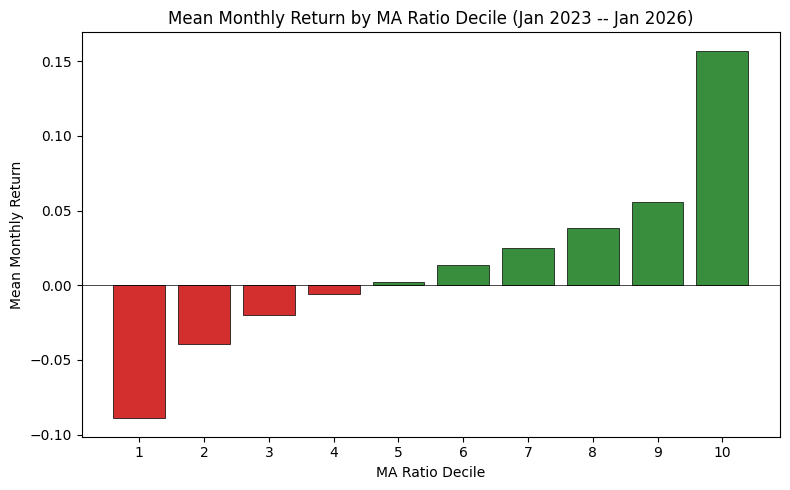

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#d32f2f" if r < 0 else "#388e3c" for r in ma_dec_avg.values]
ax.bar(
    ma_dec_avg.index.astype(int), ma_dec_avg.values,
    color=colors, edgecolor="black", linewidth=0.5
)
ax.set_xlabel("MA Ratio Decile")
ax.set_ylabel("Mean Monthly Return")
ax.set_title("Mean Monthly Return by MA Ratio Decile (Jan 2023 -- Jan 2026)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(range(1, 11))
plt.tight_layout()
plt.show()

In [8]:
df.to_parquet("exercise01_data_with_ma.parquet", index=False)
print(f"Saved exercise01_data_with_ma.parquet: {len(df):,} rows")

Saved exercise01_data_with_ma.parquet: 127,863 rows
